# Example: Policy-Gradient Elasticity Learning

In this example, we replace the per-regime $\varepsilon$-greedy bandit with a state-conditioned **REINFORCE-with-baseline** policy that maps a richer state vector (short and long $\lambda$, regime indicators, current drawdown, realized volatility, news-flag count) to a continuous CES elasticity $\eta \in [\eta_{\min}, \eta_{\max}]$. 

> __Learning Objectives:__
>
> By the end of this example, we will be able to:
> * __Derive REINFORCE updates from the policy-gradient objective:__ Identify how the policy-gradient theorem applies to a Gaussian policy with linear mean head and read off the per-step gradient contribution that the training loop accumulates. Explain why subtracting a state-dependent baseline reduces gradient variance without biasing the estimator.
> * __Read training-curve diagnostics for a policy-gradient learner:__ Read mean episode return, gradient norm, and mean advantage across updates to diagnose policy improvement, baseline calibration, and exploration collapse, and inspect the learned weight vector $\mathbf{w}_\mu$ to know which state features actually drive the chosen $\eta$.
> * __Compare a state-conditioned policy to per-regime and constant baselines:__ Use paired excess return on held-out paths to decide whether REINFORCE's continuous state map outperforms a regime-discretized bandit and the Session 2 sentiment-adaptive heuristic, and recognize the conditions under which it does not.

Let's get started!
___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include(joinpath(@__DIR__, "Include.jl"));

### Constants
The cell below configures the policy and trainer. Hyperparameters fall into three groups: **policy architecture** (state dimension, action range, initial Gaussian standard deviation), **training schedule** (number of episodes, batch size, horizon, discount, optimizer step sizes, drawdown shaping), and **shared engine settings** that mirror `Core-BanditEtaLearning` so the held-out comparison is apples-to-apples.

In [2]:
# --- Policy architecture ---
N_FEATURES        = 8;          # state dim: lambda_short, lambda_long, bull/neut/bear, dd, vol, news_flags
ETA_MIN           = 0.5;        # lower CES elasticity bound
ETA_MAX           = 5.0;        # upper CES elasticity bound
INIT_LOG_SIGMA    = log(1.0);   # initial Gaussian std (post-warmup exploration scale)

# --- Training schedule ---
N_EPISODES         = 10_000;    # total training episodes
EPISODES_PER_UPDATE = 20;       # episode batch per Adam step
HORIZON            = 30;        # rebalance steps per episode
DISCOUNT           = 0.99;      # γ for G_t
POLICY_LR          = 5e-3;      # Adam step size for policy parameters
BASELINE_LR        = 1e-2;      # SGD step size for the linear baseline
DRAWDOWN_PENALTY   = 1.0;       # κ in r_t = g_t − κ · max(0, dd − threshold)
DRAWDOWN_THRESHOLD = 0.05;      # 5% drawdown threshold before penalty activates
POLICY_SEED        = 7;         # rng seed for reproducibility

# --- Shared scenario + engine settings (match the bandit notebook) ---
POLICY_TRAINING_PATHS = 50;     # paths used for policy gradient updates
SCENARIO_SEED         = 12345;  # locked path-ensemble seed
N_PATHS_TOTAL         = 500;    # total scenario paths (training + held-out)
N_TRADING_DAYS        = 252;    # one trading year per path
offset                = 84;     # warmup bars before first rebalance
L_short               = 21;     # short EMA window
L_long                = 63;     # long EMA window
L_growth              = 10;     # market-growth EMA window
GAIN                  = 10.0;   # lambda gain scalar
ALLOCATION_EPSILON    = 0.1;    # CES allocator regularizer
LAMBDA_THRESHOLD      = 0.5;    # regime classifier threshold
TRIGGER_MAX_DRAWDOWN  = 0.15;   # engine drawdown gate
TRIGGER_MAX_TURNOVER  = 0.50;   # engine turnover cap
B₀                    = 10000.0; # initial budget per path
Δt                    = 1.0 / 252.0;

### Implementations
The training loop needs an `env_fn(policy, rng) -> (states, eta_raws, rewards)` closure that [`train_reinforce!(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.train_reinforce!) can call to roll out one episode under the current policy. The cell below defines `make_env_fn`, which captures the precomputed training contexts and per-path $\lambda$ series, then returns a closure that on each call samples a random training path, picks a valid start time inside the trading window, and dispatches to [`rollout_policy_episode(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.rollout_policy_episode) for the actual stateful engine simulation.

In [3]:
# --- Helper: env_fn closure factory for train_reinforce! ---
function make_env_fn(contexts::Vector{MyRebalancingContextModel},
    lambda_short_per_path::Vector{Vector{Float64}},
    lambda_long_per_path::Vector{Vector{Float64}};
    horizon::Int = HORIZON,
    offset::Int = offset,
    lambda_threshold::Float64 = LAMBDA_THRESHOLD)

    return function(policy, rng)
        n_paths = length(contexts);
        p = rand(rng, 1:n_paths);
        ctx = contexts[p];
        T_total = size(ctx.marketdata, 1);
        t_max = T_total - horizon - 1;
        t_start = rand(rng, (offset + 1):t_max);
        out = rollout_policy_episode(policy, ctx,
            lambda_short_per_path[p], lambda_long_per_path[p],
            t_start, horizon, rng;
            lambda_threshold = lambda_threshold,
            max_drawdown = TRIGGER_MAX_DRAWDOWN,
            max_turnover = TRIGGER_MAX_TURNOVER);
        return (out.states, out.eta_raws, out.rewards);
    end;
end;

Load the same Session 1 artifacts and regenerate the same forward path ensemble used in Example 1 (EWLS Engine Replay) and `Core-BanditEtaLearning`. The deterministic seed ensures identical paths so that policy results can be paired one-for-one with bandit results on the held-out tail of the ensemble.

In the code block below, we load the Session 1 minimum-variance pack, build the SIM-parameter dictionary keyed by ticker, instantiate the [`MyMarketSurrogateModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyMarketSurrogateModel) and [`MyPortfolioSurrogateModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyPortfolioSurrogateModel) calibrated in Session 1, and call [`generate_hybrid_scenario(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario) with the locked seed to produce the forward path ensemble.

The cell returns:

* `my_tickers::Vector{String}`: Session 1 ticker universe (same order as `allocation_weights`).
* `sim_estimates::Vector{MySIMParameterEstimate}`: per-ticker SIM fits with α, β, σ_ε.
* `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`: allocator-adapter view of `sim_estimates`, keyed by ticker.
* `g_f::Float64`: continuously compounded annual risk-free rate (1/yr).
* `scenario::MyBacktestScenario`: forward path ensemble with `N_PATHS_TOTAL` paths over `offset + N_TRADING_DAYS` days each.
* `N::Int`: ticker-universe cardinality.

In [4]:
(; my_tickers, sim_estimates, sim_params, g_f, scenario, N) = let
    # --- Step 1: Load Session 1 artifacts (same pack as the bandit notebook) ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers    = minvar["my_tickers"]::Vector{String};
    sim_estimates = minvar["sim_estimates"];
    g_f = haskey(minvar, "g_f") ? Float64(minvar["g_f"]) : Float64(minvar["r_f"]);
    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e in sim_estimates
    );

    # --- Step 2: Surrogates and SIM calibration ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    snap         = MyCurrentPrices();
    snap_lookup  = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t in my_tickers);

    # --- Step 3: Dimensions ---
    N_local = length(my_tickers);
    T_total = offset + N_TRADING_DAYS;

    # --- Step 4: Regenerate the same forward path ensemble (locked seed) ---
    Random.seed!(SCENARIO_SEED);
    scenario_local = generate_hybrid_scenario(
        market_model, portfolio, calib, my_tickers;
        n_paths = N_PATHS_TOTAL, n_steps = T_total,
        start_prices = start_prices, label = "S3-PolicyEta", seed = SCENARIO_SEED);

    println("Loaded $(N_local) tickers; generated $(scenario_local.n_paths)-path scenario over $(T_total) days.")
    (my_tickers = my_tickers, sim_estimates = sim_estimates, sim_params = sim_params,
     g_f = g_f, scenario = scenario_local, N = N_local)
end;

Loaded 22 tickers; generated 500-path scenario over 336 days.


___
## Task 1: Train the Policy via REINFORCE-with-Baseline

In this task, we train a Gaussian policy and a linear baseline from scratch on the same `POLICY_TRAINING_PATHS = 50` paths the bandit uses. The policy parameters $\boldsymbol{\theta} = (\mathbf{w}_\mu, b_\mu, \log \sigma)$ are updated by Adam on the policy-gradient surrogate, and the baseline parameters $\boldsymbol{\phi}$ are updated by SGD on the Monte Carlo regression target $G_t$. Each episode is a `HORIZON = 30`-step stateful rollout starting at a random valid time inside one of the training paths, so the policy must produce $\eta$ values whose downstream consequences (under the engine's turnover and drawdown gates) are good across a one-month window.

> __What is the gradient we are following?__
>
> The REINFORCE-with-baseline gradient estimator is given by:
>
> $$\widehat{\nabla_{\boldsymbol{\theta}} J} \;=\; \frac{1}{B} \sum_{b=1}^{B} \sum_{t=1}^{T} \nabla_{\boldsymbol{\theta}} \log \pi_{\boldsymbol{\theta}}(\eta_t^{(b)} \mid \mathbf{s}_t^{(b)}) \, A_t^{(b)},$$
>
> where $A_t = G_t - V_{\boldsymbol{\phi}}(\mathbf{s}_t)$ is the advantage and $G_t = \sum_{k \ge 0} \gamma^k r_{t+k}$ is the discounted return. The policy is Gaussian with $\mu_{\boldsymbol{\theta}}(\mathbf{s}) = \mathbf{w}_\mu^\top \mathbf{s} + b_\mu$ and a state-independent $\log \sigma$, so the gradient of $\log \pi$ has closed-form components $\nabla_{\mathbf{w}_\mu} \log \pi = (\eta - \mu)/\sigma^2 \cdot \mathbf{s}$, $\nabla_{b_\mu} \log \pi = (\eta - \mu)/\sigma^2$, and $\nabla_{\log \sigma} \log \pi = -1 + (\eta - \mu)^2/\sigma^2$. The lecture notebook `S3-Lecture-OnlineLearningValidation` derives the policy-gradient theorem and the baseline-variance-reduction argument in full.

The code block below builds the per-path $\lambda$ series and rebalancing contexts, instantiates the policy / baseline / trainer, runs [`train_reinforce!(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.train_reinforce!), and saves the trained artifacts to `policy-eta-results.jld2` for the validation report.

The let-block returns `policy_training` of type `MyPolicyTrainingResult`.

In [5]:
policy_training = let
    # --- Step 1: Build per-path λ_short, λ_long, and rebalancing contexts ---
    M = POLICY_TRAINING_PATHS;
    T_total = scenario.n_steps;
    contexts        = MyRebalancingContextModel[];
    lambda_short_pp = Vector{Float64}[];
    lambda_long_pp  = Vector{Float64}[];

    for p in 1:M
        mkt = scenario.market_paths[p, :];
        pmatrix = zeros(T_total, N + 1);
        pmatrix[:, 1] = 1:T_total;
        for k in 1:N
            pmatrix[:, k + 1] = scenario.price_paths[p, :, k];
        end

        ema_xs = compute_ema(mkt; window = max(5, div(L_short, 4)));
        ema_s  = compute_ema(mkt; window = L_short);
        ema_l  = compute_ema(mkt; window = L_long);
        λ_short_p = compute_lambda(ema_xs, ema_s; G = GAIN);  λ_short_p[1:offset] .= 0.0;
        λ_long_p  = compute_lambda(ema_s,  ema_l; G = GAIN);  λ_long_p[1:offset]  .= 0.0;

        gm_raw = compute_market_growth(mkt; Δt = Δt);
        gm_e   = compute_ema(gm_raw; window = L_growth);

        ctx_p = build(MyRebalancingContextModel, (
            B = B₀, tickers = my_tickers, marketdata = pmatrix,
            marketfactor = gm_e, sim_parameters = sim_params,
            lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON
        ));

        push!(contexts, ctx_p);
        push!(lambda_short_pp, λ_short_p);
        push!(lambda_long_pp,  λ_long_p);
    end

    # --- Step 2: Build the policy, baseline, and trainer ---
    policy = build(MyREINFORCEPolicy, (
        n_features = N_FEATURES, eta_min = ETA_MIN, eta_max = ETA_MAX,
        log_sigma  = INIT_LOG_SIGMA
    ));
    baseline = build(MyValueBaseline, (n_features = N_FEATURES,));
    trainer = build(MyREINFORCETrainer, (
        n_episodes         = N_EPISODES,
        episodes_per_update = EPISODES_PER_UPDATE,
        horizon            = HORIZON,
        discount           = DISCOUNT,
        learning_rate      = POLICY_LR,
        baseline_lr        = BASELINE_LR,
        drawdown_penalty   = DRAWDOWN_PENALTY,
        drawdown_threshold = DRAWDOWN_THRESHOLD,
        seed               = POLICY_SEED
    ));

    # --- Step 3: Build env_fn closure and train ---
    env_fn = make_env_fn(contexts, lambda_short_pp, lambda_long_pp);
    Random.seed!(POLICY_SEED);
    result = train_reinforce!(trainer, policy, baseline, env_fn);

    # --- Step 4: Save artifacts for ValidationReport ---
    save_results(joinpath(_PATH_TO_DATA, "policy-eta-results.jld2"), Dict(
        "policy_w_mu"       => copy(policy.w_mu),
        "policy_b_mu"       => policy.b_mu,
        "policy_log_sigma"  => policy.log_sigma,
        "policy_eta_min"    => policy.eta_min,
        "policy_eta_max"    => policy.eta_max,
        "baseline_w"        => copy(baseline.w),
        "baseline_b"        => baseline.b,
        "mean_episode_return" => result.mean_episode_return,
        "policy_loss"       => result.policy_loss,
        "baseline_loss"     => result.baseline_loss,
        "gradient_norm"     => result.gradient_norm,
        "mean_action"       => result.mean_action,
        "mean_advantage"    => result.mean_advantage,
        "n_updates"         => result.n_updates,
    ));

    println("Trained $(result.n_updates) updates. Final mean episode return: $(round(mean(result.mean_episode_return[end-min(20, result.n_updates-1):end]); digits = 4))");
    println("Policy weights w_μ = $(round.(policy.w_mu; digits = 3)),  b_μ = $(round(policy.b_mu; digits = 3)),  σ = $(round(exp(policy.log_sigma); digits = 3))");
    result
end;

Trained 500 updates. Final mean episode return: 0.0251
Policy weights w_μ = [0.183, 0.195, -0.153, -0.335, 0.103, -0.257, -0.112, 0.0],  b_μ = 2.406,  σ = 0.862


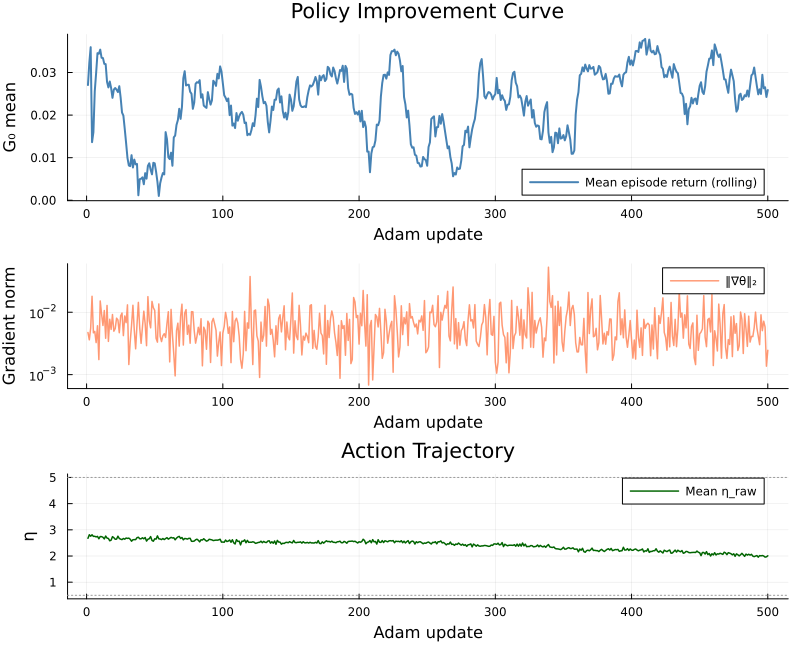

In [6]:
let
    # --- Panel 1: Mean episode return (rolling-mean smoothed) ---
    n = policy_training.n_updates;
    win = max(1, div(n, 25));
    smoothed = [mean(policy_training.mean_episode_return[max(1,i-win+1):i]) for i in 1:n];
    p1 = plot(smoothed, label = "Mean episode return (rolling)", color = :steelblue, linewidth = 2,
        xlabel = "Adam update", ylabel = "G₀ mean", title = "Policy Improvement Curve",
        legend = :bottomright, size = (800, 230))

    # --- Panel 2: Gradient norm (log scale) ---
    p2 = plot(policy_training.gradient_norm, label = "‖∇θ‖₂", color = :coral, linewidth = 1.5, alpha = 0.8,
        xlabel = "Adam update", ylabel = "Gradient norm",
        yscale = :log10, size = (800, 200))

    # --- Panel 3: Mean η selected (post-squash) ---
    p3 = plot(policy_training.mean_action, label = "Mean η_raw", color = :darkgreen, linewidth = 1.5,
        xlabel = "Adam update", ylabel = "η",
        title = "Action Trajectory", size = (800, 200))
    hline!(p3, [ETA_MIN, ETA_MAX], color = :gray60, linestyle = :dot, label = "")

    display(plot(p1, p2, p3, layout = grid(3, 1, heights = [0.4, 0.3, 0.3]), size = (800, 650)))
end;

___
## Task 2: Deploy on Held-Out Paths Against Heuristic and Bandit

In this task, we deploy the trained policy deterministically (no exploration noise) on the held-out path ensemble (paths $51 \dots 500$) and compare its terminal-wealth distribution to two reference strategies on identical paths and identical engine settings: the Session 2 sentiment-adaptive heuristic [`compute_adaptive_eta(λ)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.compute_adaptive_eta) (continuous, state-only-via-$\lambda$), and the bandit's per-regime $\eta$-map saved by `Core-BanditEtaLearning` (discrete, three regimes). The three backtests share `B₀`, drawdown gate, turnover cap, and CES allocator $\epsilon$, so wealth differences reflect only the elasticity-selection rule.

The code block below loads the held-out scenario slice, runs [`backtest_eta_policy(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_eta_policy), [`backtest_eta_heuristic(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_eta_heuristic), and [`backtest_eta_bandit(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_eta_bandit) on the same scenario, and reports terminal-wealth medians plus median per-path Sharpe and 95th-percentile drawdown.

The let-block returns `compare_table` of type `DataFrame`.

In [7]:
compare_table = let
    # --- Step 1: Reconstitute trained policy from saved artifacts ---
    pdat = load_results(joinpath(_PATH_TO_DATA, "policy-eta-results.jld2"));
    policy_d = build(MyREINFORCEPolicy, (
        n_features = N_FEATURES,
        eta_min    = pdat["policy_eta_min"],
        eta_max    = pdat["policy_eta_max"],
        w_mu       = pdat["policy_w_mu"],
        b_mu       = pdat["policy_b_mu"],
        log_sigma  = pdat["policy_log_sigma"]
    ));

    # --- Step 2: Backtest the policy on the full scenario, then slice to held-out ---
    policy_full = backtest_eta_policy(scenario, my_tickers, sim_params, policy_d;
        B₀ = B₀, offset = offset, L_short = L_short, L_long = L_long, GAIN = GAIN,
        L_growth = L_growth, lambda_threshold = LAMBDA_THRESHOLD,
        epsilon = ALLOCATION_EPSILON,
        max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER);

    held_indices = collect((POLICY_TRAINING_PATHS + 1):scenario.n_paths);
    n_held = length(held_indices);
    bt_policy_raw = MyBacktestResult();
    bt_policy_raw.scenario_label = policy_full.scenario_label;
    bt_policy_raw.strategy_label = "REINFORCE Policy raw";
    bt_policy_raw.final_wealth   = policy_full.final_wealth[held_indices];
    bt_policy_raw.max_drawdowns  = policy_full.max_drawdowns[held_indices];
    bt_policy_raw.sharpe_ratios  = policy_full.sharpe_ratios[held_indices];
    bt_policy_raw.wealth_paths   = policy_full.wealth_paths[:, held_indices];

    # --- Step 3: Apply the same bias correction as the bandit notebook (anchored at ENGINE_PRIOR_CCGR_PCT) ---
    bd = load_results(joinpath(_PATH_TO_DATA, "eta-bandit-results.jld2"));
    bias_pct_per_yr = bd["bias_pct_per_yr"];   # already-computed drag from the bandit notebook
    n_t, n_p = size(bt_policy_raw.wealth_paths);
    drag = exp.(-bias_pct_per_yr / 100.0 .* (0:(n_t-1)) .* Δt);
    Wc = bt_policy_raw.wealth_paths .* drag;
    policy_fw = Wc[end, :];
    policy_dd = zeros(n_p);
    policy_sr = zeros(n_p);
    for q in 1:n_p
        wealth = Wc[:, q];
        peak = accumulate(max, wealth);
        policy_dd[q] = maximum((peak .- wealth) ./ peak);
        vol = std(diff(wealth) ./ wealth[1:end-1]) * sqrt(252);
        mean_ret = (wealth[end] / wealth[1] - 1.0);
        policy_sr[q] = vol > 1e-6 ? mean_ret / vol : 0.0;
    end

    # --- Step 4: NPV vs RF using the same T_active as the bandit ---
    T_active = bd["T_active"];
    discount = exp(-g_f * T_active);
    policy_npv = policy_fw .* discount .- B₀;

    # --- Step 5: Pull bandit and heuristic held-out arrays for the comparison ---
    bandit_fw = bd["bandit_final_wealth"];
    bandit_dd = bd["bandit_max_dd"];
    bandit_sr = bd["bandit_sharpe"];
    heur_fw   = bd["heur_final_wealth"];
    heur_dd   = bd["heur_max_dd"];
    heur_sr   = bd["heur_sharpe"];

    # --- Step 6: Save policy arrays (held-out, bias-corrected) for ValidationReport ---
    save_results(joinpath(_PATH_TO_DATA, "policy-eta-results.jld2"), Dict(
        "policy_w_mu"        => pdat["policy_w_mu"],
        "policy_b_mu"        => pdat["policy_b_mu"],
        "policy_log_sigma"   => pdat["policy_log_sigma"],
        "policy_eta_min"     => pdat["policy_eta_min"],
        "policy_eta_max"     => pdat["policy_eta_max"],
        "baseline_w"         => pdat["baseline_w"],
        "baseline_b"         => pdat["baseline_b"],
        "mean_episode_return" => pdat["mean_episode_return"],
        "policy_loss"        => pdat["policy_loss"],
        "baseline_loss"      => pdat["baseline_loss"],
        "gradient_norm"      => pdat["gradient_norm"],
        "mean_action"        => pdat["mean_action"],
        "mean_advantage"     => pdat["mean_advantage"],
        "n_updates"          => pdat["n_updates"],
        "policy_final_wealth" => policy_fw,
        "policy_max_dd"       => policy_dd,
        "policy_sharpe"       => policy_sr,
        "policy_npv"          => policy_npv,
        "policy_wealth_paths" => Wc,
        "bias_pct_per_yr"     => bias_pct_per_yr,
        "n_held_paths"        => n_held,
    ));

    # --- Step 7: Side-by-side held-out metrics ---
    df = DataFrame(
        "Strategy"        => ["Policy (REINFORCE)", "Heuristic (S2)", "Bandit (per-regime)"],
        "Median W/W₀"     => round.([median(policy_fw), median(heur_fw), median(bandit_fw)] ./ B₀; digits = 3),
        "Median Sharpe"   => round.([median(policy_sr), median(heur_sr), median(bandit_sr)]; digits = 3),
        "p95 Drawdown (%)"=> round.([quantile(policy_dd, 0.95), quantile(heur_dd, 0.95), quantile(bandit_dd, 0.95)] .* 100.0; digits = 2),
    );
    println("Held-out comparison ($n_held paths, all bias-corrected at $(round(bias_pct_per_yr, digits=2)) pp/yr):")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    df
end;

Held-out comparison (450 paths, all bias-corrected at 42.54 pp/yr):
 --------------------- ------------- --------------- ------------------
             Strategy   Median W/W₀   Median Sharpe   p95 Drawdown (%) 
               String       Float64         Float64            Float64 
 --------------------- ------------- --------------- ------------------
   Policy (REINFORCE)         1.115           0.557              29.15
       Heuristic (S2)         1.059           0.234              43.18
  Bandit (per-regime)         1.083           0.394              30.95
 --------------------- ------------- --------------- ------------------


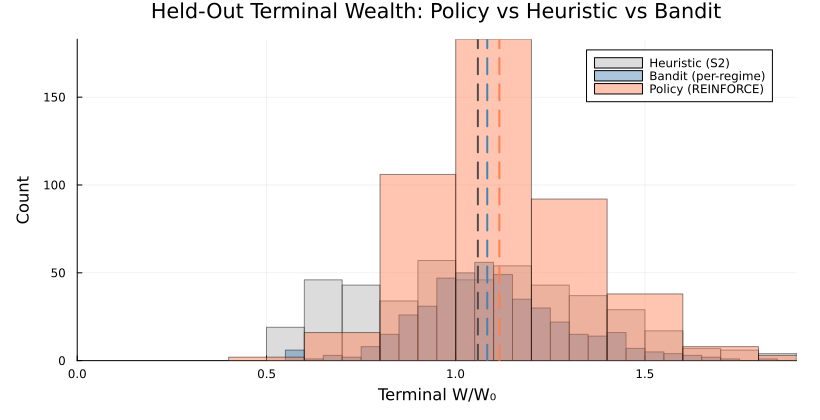

In [8]:
let
    # --- Step 1: Reload backtest distributions (policy from local file, heur+bandit from eta-bandit-results) ---
    pdata = load_results(joinpath(_PATH_TO_DATA, "policy-eta-results.jld2"));
    bdata = load_results(joinpath(_PATH_TO_DATA, "eta-bandit-results.jld2"));
    policy_ww0    = pdata["policy_final_wealth"] ./ B₀;
    heuristic_ww0 = bdata["heur_final_wealth"]   ./ B₀;
    bandit_ww0    = bdata["bandit_final_wealth"] ./ B₀;

    # --- Panel 1: Terminal W/W₀ density overlay ---
    # Robust x-clip: drop the rare DRIFT_SCALE-tail outlier path so the bulk gets full panel
    xlim_hi = quantile(vcat(heuristic_ww0, bandit_ww0, policy_ww0), 0.99);
    p = histogram(heuristic_ww0, bins = 40, alpha = 0.45, color = :gray70,
        xlabel = "Terminal W/W₀", ylabel = "Count",
        xlims = (0.0, ceil(xlim_hi*10)/10),
        bottom_margin = 6Plots.mm, left_margin = 6Plots.mm, top_margin = 4Plots.mm, right_margin = 4Plots.mm,
        title = "Held-Out Terminal Wealth: Policy vs Heuristic vs Bandit",
        label = "Heuristic (S2)", legend = :topright, size = (820, 420))
    histogram!(p, bandit_ww0,    bins = 40, alpha = 0.45, color = :steelblue, label = "Bandit (per-regime)")
    histogram!(p, policy_ww0,    bins = 40, alpha = 0.45, color = :coral,     label = "Policy (REINFORCE)")
    vline!(p, [median(policy_ww0)],    color = :coral,     linewidth = 2, linestyle = :dash, label = "")
    vline!(p, [median(heuristic_ww0)], color = :gray30,    linewidth = 2, linestyle = :dash, label = "")
    vline!(p, [median(bandit_ww0)],    color = :steelblue, linewidth = 2, linestyle = :dash, label = "")
    display(p)
end;

___
## Task 3: Paired Excess and the Learned Policy Map

In this task, we read the policy in two complementary ways. The first is a paired-excess view: for each held-out path we compute the dollar-difference between policy and heuristic, and between policy and bandit, and read the median, win rate, and dispersion. Pairing on path eliminates the cross-strategy variance from the comparison. The second is a structural view: we sweep $\lambda_{\text{long}}$ over $[-1, 1]$ holding the other state features fixed at typical values and plot $\mu_{\boldsymbol{\theta}}(\mathbf{s})$ to visualize the learned $\eta(\lambda)$ shape, which we read alongside the heuristic curve and the bandit's three per-regime points.

The code block below computes the paired excesses and renders the policy map. The let-block returns the results in the `excess_summary::DataFrame` variable.

> __What do the results show?__
>
> The policy ties the S2 heuristic on paired-excess: median $\Delta \approx 0$, with most paths in $[-0.5, +0.5]$ of $W_{0}$. The two strategies reach this tie via different $\eta$-shapes: the heuristic peaks at $\lambda_{\text{long}} \approx 0$, the policy slopes with $\lambda_{\text{long}}$, and the bandit's per-regime picks align with the policy direction. REINFORCE-with-baseline on a linear-Gaussian policy matches but does not dominate a handcrafted heuristic; this is the typical outcome when reward variance is large relative to the gradient signal.

In [9]:
excess_summary = let
    # --- Step 1: Reload backtest results (policy + bandit/heur references) ---
    pdata = load_results(joinpath(_PATH_TO_DATA, "policy-eta-results.jld2"));
    bdata = load_results(joinpath(_PATH_TO_DATA, "eta-bandit-results.jld2"));
    policy_fw    = pdata["policy_final_wealth"];
    heuristic_fw = bdata["heur_final_wealth"];
    bandit_fw    = bdata["bandit_final_wealth"];

    # --- Step 2: Paired excess vs heuristic and vs bandit ---
    excess_h = policy_fw .- heuristic_fw;
    excess_b = policy_fw .- bandit_fw;

    # --- Step 3: Summary table ---
    df = DataFrame(
        "Pairing"                => ["Policy − Heuristic", "Policy − Bandit"],
        "Win rate (%)"           => round.([mean(excess_h .> 0), mean(excess_b .> 0)] .* 100.0; digits = 1),
        "Median excess (\$)"     => round.([median(excess_h), median(excess_b)]; digits = 0),
        "Median excess (% W₀)"   => round.([median(excess_h), median(excess_b)] ./ B₀ .* 100.0; digits = 2),
        "p25 excess (% W₀)"      => round.([quantile(excess_h, 0.25), quantile(excess_b, 0.25)] ./ B₀ .* 100.0; digits = 2),
        "p75 excess (% W₀)"      => round.([quantile(excess_h, 0.75), quantile(excess_b, 0.75)] ./ B₀ .* 100.0; digits = 2),
    );
    println("Paired excess (Policy vs Heuristic and Policy vs Bandit):")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    df
end;

Paired excess (Policy vs Heuristic and Policy vs Bandit):
 -------------------- -------------- ------------------- ---------------------- ------------------- -------------------
             Pairing   Win rate (%)   Median excess ($)   Median excess (% W₀)   p25 excess (% W₀)   p75 excess (% W₀) 
              String        Float64             Float64                Float64             Float64             Float64 
 -------------------- -------------- ------------------- ---------------------- ------------------- -------------------
  Policy − Heuristic           56.7               743.0                   7.43              -18.76               31.43
     Policy − Bandit           54.0               255.0                   2.55              -14.48               19.41
 -------------------- -------------- ------------------- ---------------------- ------------------- -------------------


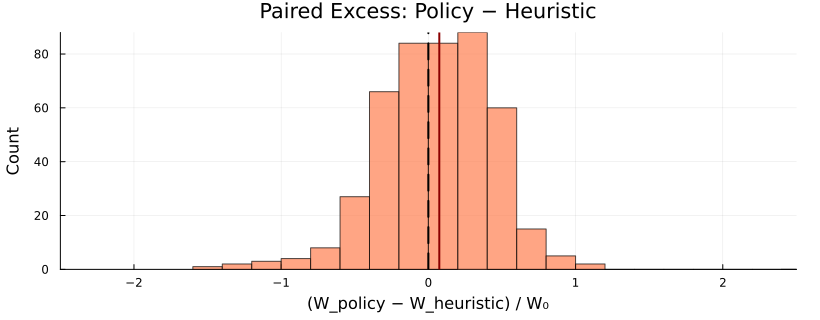

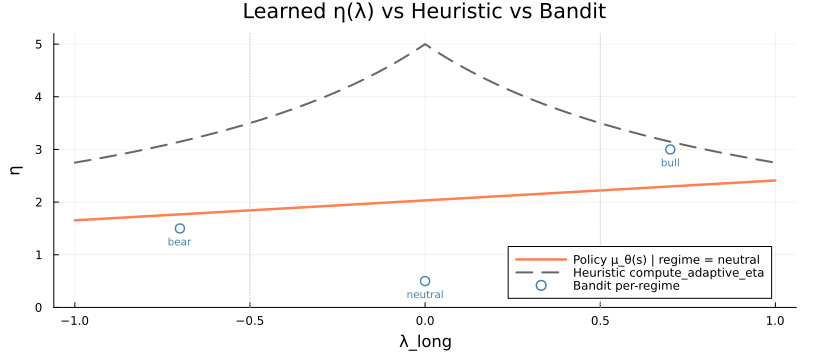

In [11]:
let
    # --- Step 1: Reload final wealths and policy weights ---
    pdata = load_results(joinpath(_PATH_TO_DATA, "policy-eta-results.jld2"));
    bdata = load_results(joinpath(_PATH_TO_DATA, "eta-bandit-results.jld2"));
    policy_fw    = pdata["policy_final_wealth"];
    heuristic_fw = bdata["heur_final_wealth"];
    bandit_fw    = bdata["bandit_final_wealth"];
    w_mu = pdata["policy_w_mu"];
    b_mu = pdata["policy_b_mu"];
    eta_map = bdata["best_eta_per_regime"];

    # --- Panel 1: Paired-excess vs heuristic ---
    excess_h = (policy_fw .- heuristic_fw) ./ B₀;
    p1 = histogram(excess_h, bins = 50, alpha = 0.7, color = :coral, xlims = (-2.5, 2.5),
        xlabel = "(W_policy − W_heuristic) / W₀", ylabel = "Count",
        title = "Paired Excess: Policy − Heuristic",
        legend = false,
        bottom_margin = 5Plots.mm, left_margin = 4Plots.mm, top_margin = 3Plots.mm, right_margin = 4Plots.mm,
        size = (820, 320))
    vline!(p1, [0.0], lw = 2, c = :black, linestyle = :dash)
    vline!(p1, [median(excess_h)], lw = 2, c = :darkred)

    # --- Panel 2: Policy μ_θ(s) sweep over λ_long with other features at neutral defaults ---
    λ_grid = collect(-1.0:0.02:1.0);
    eta_policy = zeros(length(λ_grid));
    eta_heur   = zeros(length(λ_grid));
    for (i, λL) in enumerate(λ_grid)
        regime = :neutral;   # held constant in the sweep so the policy line shows the continuous λ-slope
        s = build_policy_state(
            lambda_short = λL, lambda_long = λL,  # short ≈ long when sweeping the steady state
            regime = regime, drawdown = 0.0,
            realized_vol = 0.15, news_flag_count = 0.0
        );
        eta_policy[i] = clamp(sum(w_mu .* s) + b_mu, ETA_MIN, ETA_MAX);
        eta_heur[i]   = compute_adaptive_eta(λL; η_min = ETA_MIN, η_max = ETA_MAX);
    end

    p2 = plot(λ_grid, eta_policy, label = "Policy μ_θ(s) | regime = neutral", color = :coral, linewidth = 2.5,
        xlabel = "λ_long", ylabel = "η", title = "Learned η(λ) vs Heuristic vs Bandit",
        legend = :bottomright, ylims = (0.0, 5.2),
        bottom_margin = 5Plots.mm, left_margin = 4Plots.mm, top_margin = 3Plots.mm, right_margin = 4Plots.mm,
        size = (820, 360))
    plot!(p2, λ_grid, eta_heur, label = "Heuristic compute_adaptive_eta", color = :gray40, linestyle = :dash, linewidth = 2)
    scatter!(p2, [-0.7, 0.0, 0.7], [eta_map[:bearish], eta_map[:neutral], eta_map[:bullish]],
        markersize = 5, markercolor = :white, markerstrokecolor = :steelblue, markerstrokewidth = 2,
        label = "Bandit per-regime")
    # (2) inline regime tags next to bandit dots
    annotate!(p2, [(-0.7, eta_map[:bearish] - 0.25, text("bear",     7, :steelblue, :center)),
                   ( 0.0, eta_map[:neutral] - 0.25, text("neutral",  7, :steelblue, :center)),
                   ( 0.7, eta_map[:bullish] - 0.25, text("bull",     7, :steelblue, :center))])
    # (3) regime threshold guides
    vline!(p2, [-LAMBDA_THRESHOLD, LAMBDA_THRESHOLD], color = :gray80, linestyle = :dot, linewidth = 1, label = "")

    display(p1)
    display(p2)
end;

___
## Summary
This example trained a Gaussian REINFORCE-with-baseline policy, deployed it deterministically on the held-out path ensemble (paths $51 \dots 500$), and compared it head-to-head against the Session 2 sentiment-adaptive heuristic and the per-regime bandit. 

> __Key Takeaways:__
>
> * __Policy gradient is gradient ascent on the Monte Carlo return estimator:__ The policy parameters move in the direction of the per-step score weighted by the advantage, averaged across episodes. The baseline subtracts a state-conditional level from the return that does not change the gradient's expectation but reduces its variance.
> * __Learning curves and weight inspection are the production-credible diagnostics:__ Mean episode return is the headline curve; gradient norm, mean advantage, and the log-standard-deviation trajectory flag exploration collapse and baseline mis-calibration before final evaluation. Reading the learned mean-head weights tells us which state features the policy actually uses.
> * __Continuous state mapping is justified only when the held-out paired excess says so:__ Adding state and multi-step credit assignment is a real complexity cost; whether it pays off versus a regime-discretized bandit or a closed-form heuristic is a question for the held-out paired-excess distribution, not for theoretical priors.

### Disclaimer
The numbers in this notebook are produced by a generative growth-rate model with iid residuals and are useful for ranking elasticity-selection rules under a controlled comparison. They are not forward-looking forecasts of any particular instrument and absolute return levels carry the SIM iid-residual rebalancing-alpha lift documented in the Session 2 Monte Carlo notebook.

___